# 🧠 Mental Health Intelligence Platform

## Phase 4 — Exploratory Data Analysis

### Overview

Exploratory Data Analysis identifies patterns and trends within the dataset.

However, visual observations alone cannot determine whether these relationships are statistically significant.

This notebook applies statistical hypothesis testing to evaluate relationships between workplace characteristics and mental health outcomes.

---

### Objectives

The objectives of this notebook are to:

- Test relationships between categorical variables
- Measure the strength of statistical associations
- Identify variables associated with treatment-seeking behaviour
- Validate observations from exploratory data analysis

## Import Required Libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import plotly.express as px

from scipy.stats import chi2_contingency
from scipy.stats import spearmanr

pd.set_option("display.max_columns", None)

## Load Dataset

In [5]:
df = pd.read_csv("../../data/processed/harmonized_osmi_data.csv")

print(df.shape)

df.head()

(3082, 70)


,source_file,survey_year,self_employed,no_employees,tech_company,primary_role_tech,benefits,know_options,formal_discussion,resources,anonymity,leave_ease,comfort_physical_mental,comfort_supervisor,discussed_with_employer,comfort_coworkers,discussed_with_coworkers,coworker_discussed_with_you,employer_importance_physical,employer_importance_mental,coverage_mental_health,know_resources,reveal_to_clients,reveal_to_coworkers,productivity_affected,productivity_percent_affected,have_prev_employers,prev_tech_company,prev_benefits,prev_know_options,prev_formal_discussion,prev_resources,prev_anonymity,prev_comfort_physical_mental,prev_comfort_supervisor,prev_discussed_with_employer,prev_comfort_coworkers,prev_discussed_with_coworkers,prev_employer_importance_physical,prev_employer_importance_mental,currently_disordered,diagnosed_disorder,past_disorder,sought_treatment,family_history,interference_when_treated,interference_when_not_treated,observations_less_likely_reveal,share_with_friends_family,bring_up_physical_interview,bring_up_mental_interview,bring_up_mental_why,openly_identified,identified_affected_career,identified_affected_how,team_reaction_if_knew,observed_unsupportive_response,unsupportive_response_desc,observed_supportive_response,industry_support_rating,improvement_suggestions,additional_comments,willing_to_interview,age,gender,country_live,state_live,race,country_work,state_work
0,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,Yes,Don't Know,No,Yes,Yes,Somewhat easy,Yes,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Often,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN
1,2014,2014,NaN,More than 1000,No,NaN,Don't Know,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,No,Maybe,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
2,2014,2014,NaN,2025-06-01 00:00:00,Yes,NaN,No,No,No,No,Don't Know,Somewhat difficult,No,Yes,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Rarely,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
3,2014,2014,NaN,26-100,Yes,NaN,No,Yes,No,No,No,Somewhat difficult,No,No,Yes,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Often,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN
4,2014,2014,NaN,100-500,Yes,NaN,Yes,No,Don't Know,Don't Know,Don't Know,Don't Know,Don't know,Yes,No,Some of them,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Never,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN


## Statistical Analysis Overview

This notebook uses two primary statistical techniques:

### 1. Chi-Square Test

Used to determine whether two categorical variables are statistically associated.

### 2. Cramér's V

Measures the strength of the relationship identified by the Chi-Square Test.

Interpretation:

| Cramér's V | Strength |
|------------|----------|
| 0.00–0.10 | Negligible |
| 0.10–0.30 | Weak |
| 0.30–0.50 | Moderate |
| >0.50 | Strong |

In [6]:
import numpy as np

def cramers_v(confusion_matrix):

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))


def chi_square_test(df, col1, col2):

    table = pd.crosstab(df[col1], df[col2])

    chi2, p, dof, expected = chi2_contingency(table)

    cv = cramers_v(table)

    print("=" * 70)

    print(f"{col1} vs {col2}")

    print(f"Chi-Square : {chi2:.3f}")

    print(f"P-value    : {p:.5f}")

    print(f"Cramer's V : {cv:.3f}")

    if p < 0.05:
        print("Result     : Significant Relationship ✅")
    else:
        print("Result     : No Significant Relationship ❌")

    return {
        "Variable 1": col1,
        "Variable 2": col2,
        "Chi Square": chi2,
        "P Value": p,
        "Cramers V": cv
    }

## Family History vs Treatment

### Hypotheses

**H₀:** Family history and treatment-seeking behaviour are independent.

**H₁:** Family history and treatment-seeking behaviour are associated.

In [8]:
result1 = chi_square_test(
    df,
    "family_history",
    "sought_treatment"
)

family_history vs sought_treatment
Chi-Square : 512.403
P-value    : 0.00000
Cramer's V : 0.408
Result     : Significant Relationship ✅


## Benefits vs Treatment

This analysis investigates whether the availability of employer-sponsored mental health benefits is associated with treatment-seeking behaviour.

In [9]:
result2 = chi_square_test(
    df,
    "benefits",
    "sought_treatment"
)

benefits vs sought_treatment
Chi-Square : 145.111
P-value    : 0.00000
Cramer's V : 0.258
Result     : Significant Relationship ✅


In [10]:
result3 = chi_square_test(
    df,
    "resources",
    "sought_treatment"
)

resources vs sought_treatment
Chi-Square : 38.320
P-value    : 0.00000
Cramer's V : 0.117
Result     : Significant Relationship ✅


In [11]:
result4 = chi_square_test(
    df,
    "formal_discussion",
    "sought_treatment"
)

formal_discussion vs sought_treatment
Chi-Square : 27.826
P-value    : 0.00000
Cramer's V : 0.099
Result     : Significant Relationship ✅


In [12]:
result5 = chi_square_test(
    df,
    "anonymity",
    "sought_treatment"
)

anonymity vs sought_treatment
Chi-Square : 33.006
P-value    : 0.00000
Cramer's V : 0.108
Result     : Significant Relationship ✅


In [13]:
result6 = chi_square_test(
    df,
    "comfort_supervisor",
    "sought_treatment"
)

comfort_supervisor vs sought_treatment
Chi-Square : 4.336
P-value    : 0.22738
Cramer's V : 0.039
Result     : No Significant Relationship ❌


In [14]:
results = pd.DataFrame([

    result1,
    result2,
    result3,
    result4,
    result5,
    result6

])

results

,Variable 1,Variable 2,Chi Square,P Value,Cramers V
0,family_history,sought_treatment,512.403280,5.408061e-112,0.407746
1,benefits,sought_treatment,145.111144,2.987228e-31,0.258001
2,resources,sought_treatment,38.319556,4.775449e-09,0.116508
3,formal_discussion,sought_treatment,27.825997,9.071134e-07,0.099282
4,anonymity,sought_treatment,33.005816,6.805782e-08,0.108128
5,comfort_supervisor,sought_treatment,4.336179,2.273765e-01,0.039192


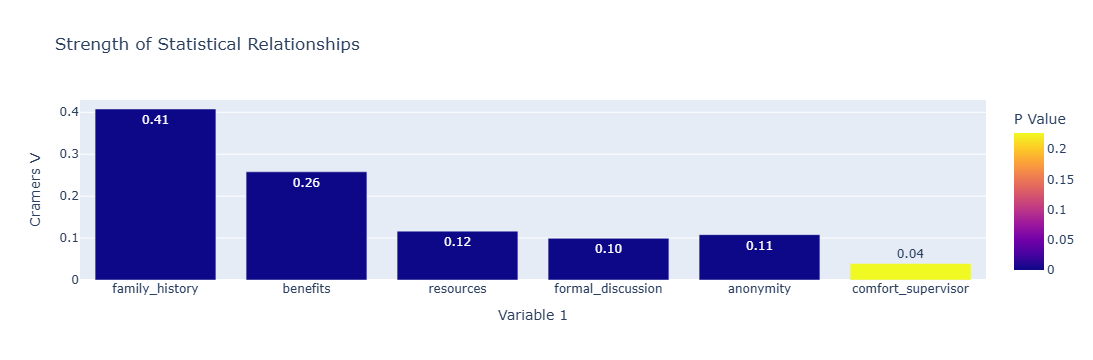

In [15]:
fig = px.bar(

    results,

    x="Variable 1",

    y="Cramers V",

    color="P Value",

    text="Cramers V",

    title="Strength of Statistical Relationships"

)

fig.update_traces(texttemplate="%{text:.2f}")

fig.show()

## Multiple Hypothesis Testing with Bonferroni Correction

In [17]:
from statsmodels.stats.multitest import multipletests

# After running all tests, apply Bonferroni correction
p_values = results['P Value'].values
rejected, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

results['P Value (Corrected)'] = pvals_corrected
results['Significant (Corrected)'] = rejected

print("\n=== Results with Bonferroni Correction ===")
print(results[['Variable 1', 'Variable 2', 'P Value', 'P Value (Corrected)', 'Significant (Corrected)']])


=== Results with Bonferroni Correction ===
           Variable 1        Variable 2        P Value  P Value (Corrected)  \
0      family_history  sought_treatment  5.408061e-112        3.244837e-111   
1            benefits  sought_treatment   2.987228e-31         1.792337e-30   
2           resources  sought_treatment   4.775449e-09         2.865270e-08   
3   formal_discussion  sought_treatment   9.071134e-07         5.442680e-06   
4           anonymity  sought_treatment   6.805782e-08         4.083469e-07   
5  comfort_supervisor  sought_treatment   2.273765e-01         1.000000e+00   

   Significant (Corrected)  
0                     True  
1                     True  
2                     True  
3                     True  
4                     True  
5                    False  


## Chi-Square Test for All Demographic Variables

In [18]:
# Define demographic columns
demo_cols = ['gender', 'age', 'race', 'country_live', 'no_employees', 'tech_company', 'primary_role_tech']
treatment_col = 'sought_treatment'

demo_results = []

for col in demo_cols:
    # Clean data - drop rows with NaN in either column
    clean_df = df[[col, treatment_col]].dropna()
    
    if len(clean_df) > 0 and len(clean_df[col].unique()) > 1:
        try:
            result = chi_square_test(clean_df, col, treatment_col)
            demo_results.append(result)
        except:
            print(f"Skipping {col} - insufficient data or categories")

demo_results_df = pd.DataFrame(demo_results)
print(demo_results_df)

gender vs sought_treatment
Chi-Square : 8.006
P-value    : 0.01826
Cramer's V : 0.051
Result     : Significant Relationship ✅
age vs sought_treatment
Chi-Square : 67.339
P-value    : 0.04207
Cramer's V : 0.192
Result     : Significant Relationship ✅
race vs sought_treatment
Chi-Square : 31.119
P-value    : 0.00028
Cramer's V : 0.168
Result     : Significant Relationship ✅
country_live vs sought_treatment
Chi-Square : 139.797
P-value    : 0.00000
Cramer's V : 0.346
Result     : Significant Relationship ✅
no_employees vs sought_treatment
Chi-Square : 25.072
P-value    : 0.00013
Cramer's V : 0.094
Result     : Significant Relationship ✅
tech_company vs sought_treatment
Chi-Square : 0.610
P-value    : 0.43474
Cramer's V : 0.015
Result     : No Significant Relationship ❌
primary_role_tech vs sought_treatment
Chi-Square : 0.643
P-value    : 0.42253
Cramer's V : 0.020
Result     : No Significant Relationship ❌
          Variable 1        Variable 2  Chi Square       P Value  Cramers V
0      

## ANOVA for Age Groups

In [20]:
from scipy.stats import f_oneway
import pandas as pd

# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)

# Prepare data for ANOVA
age_groups = []
for group in df['age_group'].dropna().unique():
    age_groups.append(df[df['age_group'] == group]['sought_treatment'].map({'Yes': 1, 'No': 0}).dropna())

# Perform ANOVA
if len(age_groups) > 1:
    f_stat, p_val = f_oneway(*age_groups)
    print(f"=== Age Group ANOVA ===")
    print(f"F-statistic: {f_stat:.3f}")
    print(f"P-value: {p_val:.5f}")
    print(f"Result: {'Significant' if p_val < 0.05 else 'Not Significant'}")
    
    # Calculate proportions by age group
    age_proportions = df.groupby('age_group')['sought_treatment'].value_counts(normalize=True).unstack()
    print("\n=== Treatment Proportion by Age ===")
    print(age_proportions)

=== Age Group ANOVA ===
F-statistic: 3.955
P-value: 0.00336
Result: Significant

=== Treatment Proportion by Age ===
sought_treatment        No       Yes
age_group                           
18-25             0.525641  0.474359
26-35             0.394928  0.605072
36-45             0.394316  0.605684
46-55             0.411043  0.588957
55+               0.317073  0.682927
